In [7]:
# =========================================================
# WEB3 WALLET BEHAVIOR & CHURN ANALYSIS PROJECT
# COMPLETE PYTHON CODE
# =========================================================

# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [11]:
# =========================
# LOAD DATASET
# =========================

 
df = pd.read_csv("C:/Users/lordb/Downloads/Cryptocurrency Transaction Data csv.csv")

In [12]:
# =========================
# VIEW DATA
# =========================

print(df.head())

   Transaction_ID                              Sender_Address  \
0  TX2QW62Q5XM17K  0xd377b9203ad74038664c08f658c0245632651f55   
1  TXQLO0O0OTW4LJ  0x82f88633d0181ac75ddf2a30e0536715323c36bb   
2  TXUQHLOGH29HUX  0x3df47b281761298334f39e351a37135e366e00bc   
3  TXOUB0QDRACX9V  0x048ec0b0375c05d8232374bee7cbf9d962003916   
4  TXITZPHD2NENA7  0x5cd4d3cc6a2f410a350c0d3ad929ec1a2f4c32f5   

                             Receiver_Address     Amount  Transaction_Fee  \
0  0x4a3370c0f0b83d519ddf50892d006f64d7425880  11.396181         0.000062   
1  0x7faeb5aa2b3c1d34bbe742dbf58a9405677983ce   9.504004         0.000043   
2          3cwt5fdejoeo52pjyayfwvyufulihttiqs   1.814056         0.000199   
3          367olmymnss867abmhfqdw9u2p4uxrcuer   4.759595         0.000704   
4  0xe166fa006fd6b7d427d19e7e28c9338ab40cd273  12.333792         0.000273   

                     Timestamp                  Block_ID Mining_Pool Currency  \
0  2025-03-30T23:32:40.589676Z  f4A4D894b9Ee166B3F75F4Fb   Etherm

In [13]:
# =========================
# CHECK COLUMNS
# =========================

print(df.columns)

Index(['Transaction_ID', 'Sender_Address', 'Receiver_Address', 'Amount',
       'Transaction_Fee', 'Timestamp', 'Block_ID', 'Mining_Pool', 'Currency',
       'Transaction_Type', 'Transaction_Status', 'Gas_Price_Gwei'],
      dtype='object')


In [14]:
# =========================
# CHECK DATA TYPES
# =========================

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      50000 non-null  object 
 1   Sender_Address      50000 non-null  object 
 2   Receiver_Address    50000 non-null  object 
 3   Amount              50000 non-null  float64
 4   Transaction_Fee     50000 non-null  float64
 5   Timestamp           50000 non-null  object 
 6   Block_ID            50000 non-null  object 
 7   Mining_Pool         50000 non-null  object 
 8   Currency            50000 non-null  object 
 9   Transaction_Type    50000 non-null  object 
 10  Transaction_Status  50000 non-null  object 
 11  Gas_Price_Gwei      25012 non-null  float64
dtypes: float64(3), object(9)
memory usage: 4.6+ MB
None


In [16]:
# =========================
# REMOVE DUPLICATES
# =========================

df.drop_duplicates(inplace=True)
print("Duplicates Removed")

Duplicates Removed


In [17]:
# =========================
# CHECK MISSING VALUES
# =========================

print(df.isnull().sum())

Transaction_ID            0
Sender_Address            0
Receiver_Address          0
Amount                    0
Transaction_Fee           0
Timestamp                 0
Block_ID                  0
Mining_Pool               0
Currency                  0
Transaction_Type          0
Transaction_Status        0
Gas_Price_Gwei        24988
dtype: int64


In [20]:
# =========================
# HANDLE MISSING VALUES
# =========================

# Check missing values

print(df['Gas_Price_Gwei'].isnull().sum())

# Fill null values with median

df['Gas_Price_Gwei'] = df['Gas_Price_Gwei'].fillna(
    df['Gas_Price_Gwei'].median()
)

# Verify again

print(df['Gas_Price_Gwei'].isnull().sum())

24988
0


In [21]:
# ===========================
# CHECK MISSING VALUES AGAIN
# ===========================

print(df.isnull().sum())

Transaction_ID        0
Sender_Address        0
Receiver_Address      0
Amount                0
Transaction_Fee       0
Timestamp             0
Block_ID              0
Mining_Pool           0
Currency              0
Transaction_Type      0
Transaction_Status    0
Gas_Price_Gwei        0
dtype: int64


In [22]:
# =========================
# CONVERT TIMESTAMP
# =========================

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [25]:
# =========================
# CONVERT NUMERIC COLUMNS
# =========================

numeric_cols = [
    'Amount',
    'Gas_Price_Gwei',
    'Transaction_Fee'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [27]:
# =========================
# REMOVE INVALID TRANSACTIONS
# =========================

df = df[df['Amount'] > 0]

In [28]:
# =========================
# SAVE CLEANED DATA
# =========================

df.to_csv(
    r"C:\Users\lordb\OneDrive\Documents\cleaned_transactions.csv",
    index=False
)

print("Cleaned data saved successfully")

Cleaned data saved successfully


In [29]:
# =========================================================
# EXPLORATORY DATA ANALYSIS
# =========================================================

# =========================
# TOTAL TRANSACTIONS
# =========================

print("Total Transactions:", len(df))

Total Transactions: 50000


In [30]:
# =========================
# UNIQUE WALLETS
# =========================

unique_wallets = pd.concat([
    df['Sender_Address'],
    df['Receiver_Address']
]).nunique()

print("Unique Wallets:", unique_wallets)

Unique Wallets: 100000


In [31]:
# =========================
# TOTAL TRANSACTION VOLUME
# =========================

print("Total Volume:", df['Amount'].sum())

Total Volume: 375954.33246031


In [32]:
# =========================
# MOST ACTIVE WALLETS
# =========================

wallet_activity = df['Sender_Address'].value_counts()

print(wallet_activity.head(10))

Sender_Address
0xd377b9203ad74038664c08f658c0245632651f55    1
0x79add1d2113cb5b774dbbb651a0c92238c6ac0fb    1
0x9d3dee16e39fe0214232ec745d51b676216ec914    1
0x2f28ca1c248f7373cfdc11df4375cb297321b4fc    1
0x321735e086d55cd62f90714bcc9c53442d96fba0    1
0x4e675199750f369bb470b388fff2cc5796f6c0c4    1
0x6e135347ce248fb824b5c42e3820e07c422cb6d6    1
0x7e477e7e5147d1ea9fb7e8e36d6b6dd809aba024    1
0xbef33e4451d78c18cb4252d251af770e10d5c994    1
0xf50e3d395fcd7164f7892fc2f6666ab12b6a18bc    1
Name: count, dtype: int64


In [35]:
# =========================
# DAILY TRANSACTION TREND
# =========================

daily_txn = df.groupby('Timestamp')['Transaction_ID'].count()

print(daily_txn.head())

Timestamp
2025-03-03 04:37:41.537595+00:00    1
2025-03-03 04:38:41.516398+00:00    1
2025-03-03 04:44:41.110629+00:00    1
2025-03-03 04:47:40.702223+00:00    1
2025-03-03 04:51:40.605600+00:00    1
Name: Transaction_ID, dtype: int64


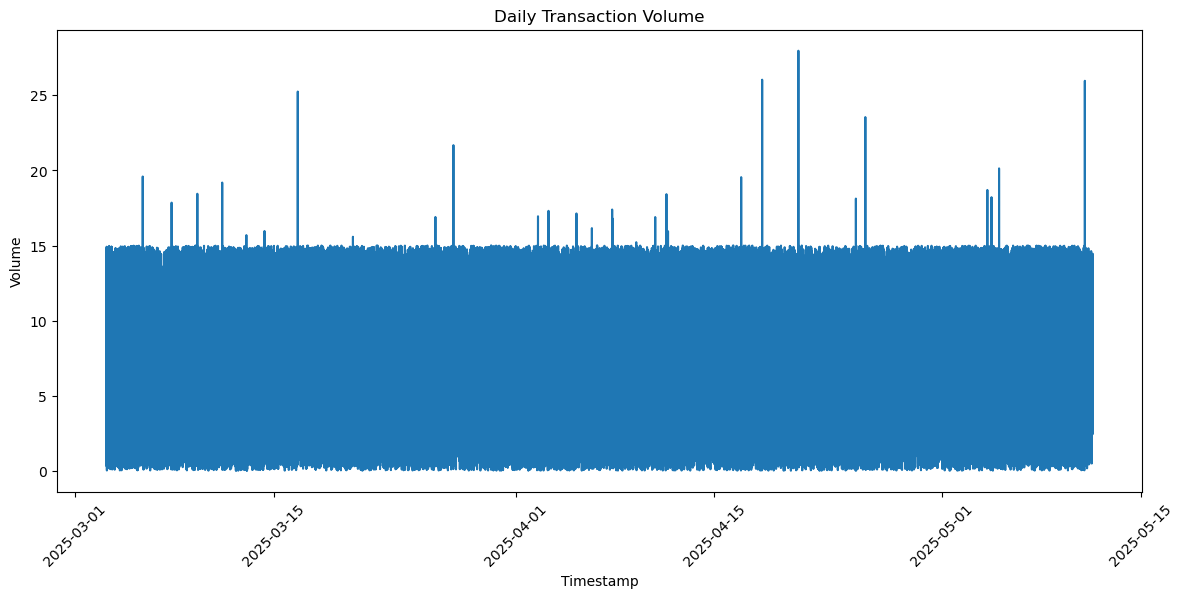

In [38]:
# =========================================================
# VISUALIZATIONS
# =========================================================

# =========================
# DAILY TRANSACTION VOLUME
# =========================

daily_volume = df.groupby('Timestamp')['Amount'].sum()

plt.figure(figsize=(14,6))

plt.plot(daily_volume)

plt.title("Daily Transaction Volume")
plt.xlabel("Timestamp")
plt.ylabel("Volume")

plt.xticks(rotation=45)

plt.show()

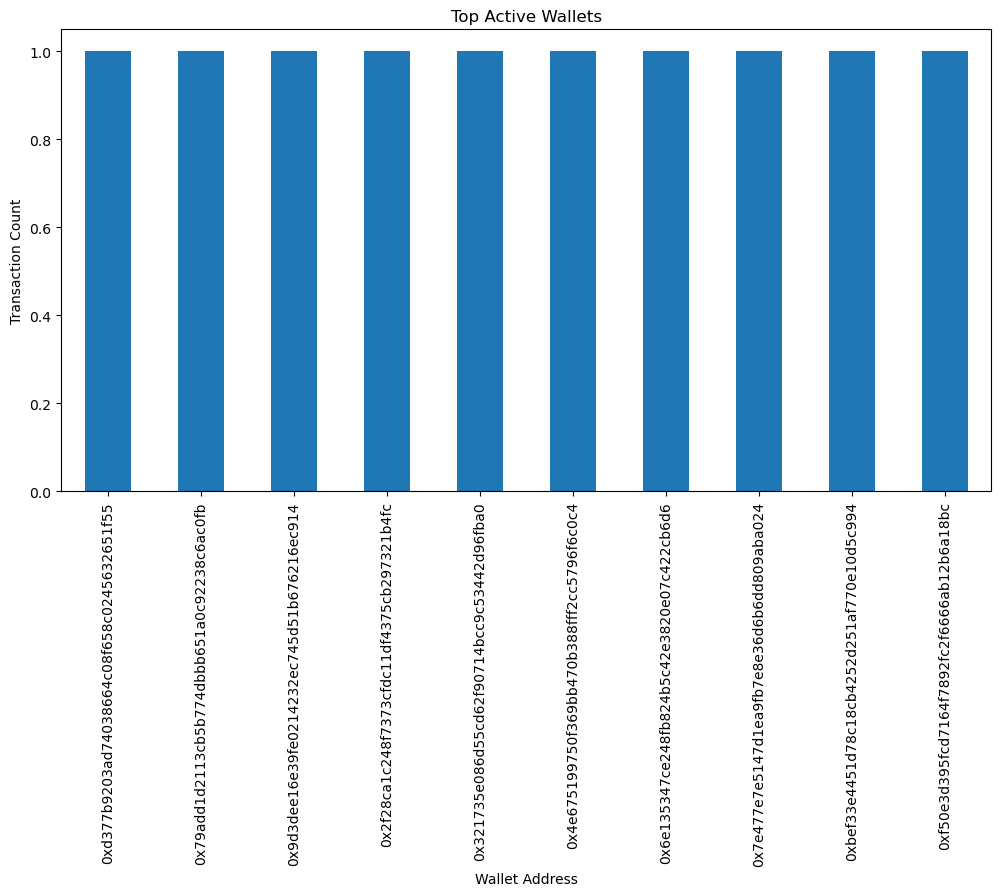

In [39]:
# =========================
# TOP ACTIVE WALLETS
# =========================

wallet_activity.head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Top Active Wallets")
plt.xlabel("Wallet Address")
plt.ylabel("Transaction Count")

plt.show()

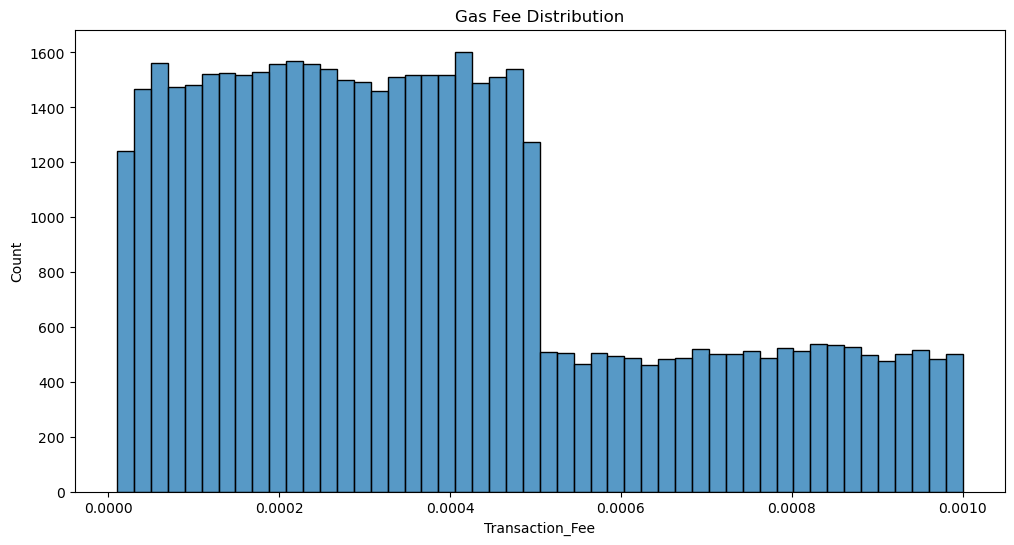

In [40]:
# =========================
# GAS FEE DISTRIBUTION
# =========================

plt.figure(figsize=(12,6))

sns.histplot(
    df['Transaction_Fee'],
    bins=50
)

plt.title("Gas Fee Distribution")

plt.show()

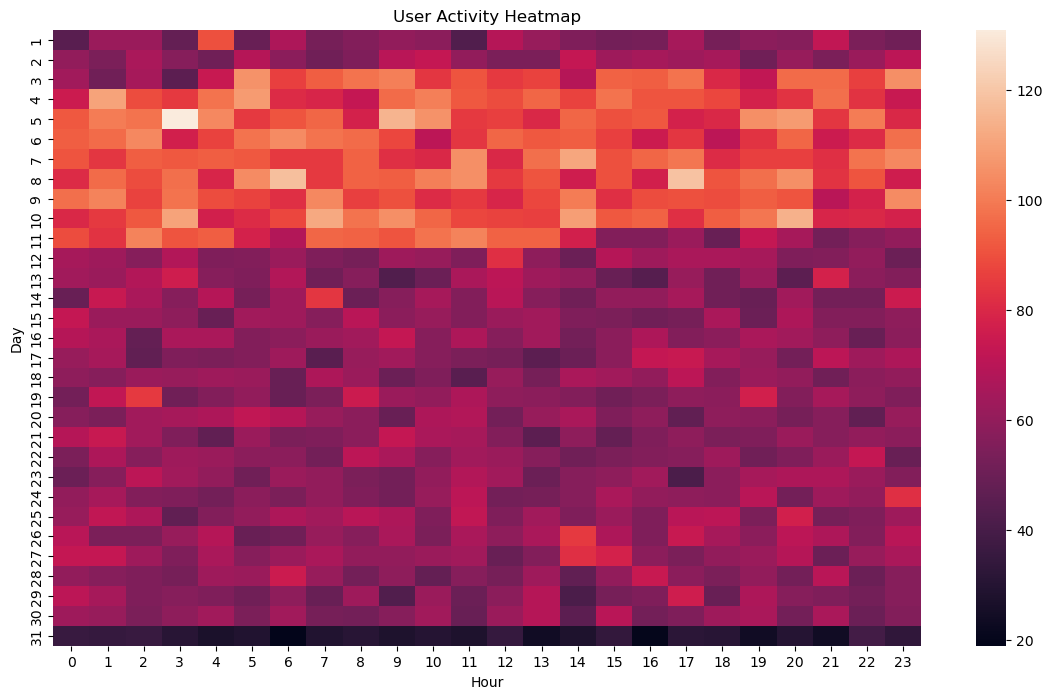

In [43]:
# =========================
# USER ACTIVITY HEATMAP
# =========================

 # Create Day and Hour columns 

df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour

# Create heatmap data

heatmap_data = df.groupby(
    ['Day', 'Hour']
)['Transaction_ID'].count().unstack()

# Plot heatmap

plt.figure(figsize=(14,8))

sns.heatmap(heatmap_data)

plt.title("User Activity Heatmap")

plt.show()

In [49]:
# =========================================================
# RFM ANALYSIS
# =========================================================

# =========================
# CREATE SNAPSHOT DATE
# =========================

snapshot_date = df['Timestamp'].max()

In [50]:
# =========================
# CREATE RFM TABLE
# =========================

rfm = df.groupby('Sender_Address').agg({

    'Timestamp': lambda x:
    (snapshot_date - x.max()).days,

    'Transaction_ID': 'count',

    'Amount': 'sum'

})

rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

print(rfm.head())

                                            Recency  Frequency  Monetary
Sender_Address                                                          
0x000175b5a901673303afce47b1f9bbb7a239a533       38          1  4.762193
0x000183da181adc0c69aeb424352a2b1707443d94       57          1  3.665944
0x00024bd9726cba2ed9fa279eac229095eb203848        3          1  3.225520
0x00039c3e282ff9f556d62bcd0b51876bc4766796       23          1  9.847970
0x00039ce5f6eb8b335cd2f57aa1a1ae39f6e3c834       59          1  0.903059


In [53]:
# =========================
# CREATE USER SEGMENTS
# =========================

rfm['Segment'] = 'Low Value'

rfm.loc[
    (rfm['Frequency'] > 10) &
    (rfm['Monetary'] > 10000),
    'Segment'
] = 'High Value'

In [54]:
# =========================
# CREATE CHURN COLUMN
# =========================

rfm['Churn'] = rfm['Recency'].apply(
    lambda x: 1 if x > 30 else 0
)

print(rfm['Churn'].value_counts())

Churn
1    27657
0    22343
Name: count, dtype: int64


In [55]:
# =========================================================
# MACHINE LEARNING MODEL
# =========================================================

# =========================
# FEATURES & TARGET
# =========================

X = rfm[['Recency', 'Frequency', 'Monetary']]

y = rfm['Churn']

In [56]:
# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
# =========================
# TRAIN MODEL
# =========================

model = RandomForestClassifier()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
# =========================
# PREDICTIONS
# =========================

predictions = model.predict(X_test)

In [61]:
# =========================
# MODEL ACCURACY
# =========================

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [62]:
# =========================
# CLASSIFICATION REPORT
# =========================

print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4537
           1       1.00      1.00      1.00      5463

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [63]:
# =========================================================
# SAVE RFM ANALYSIS
# =========================================================

rfm.to_csv(
    r"C:\Users\lordb\OneDrive\Documents\rfm_analysis.csv"
)

print("RFM Analysis saved successfully")

RFM Analysis saved successfully


In [64]:
# =========================================================
# PROJECT COMPLETED
# =========================================================

print("WEB3 WALLET BEHAVIOR ANALYSIS COMPLETED SUCCESSFULLY")


WEB3 WALLET BEHAVIOR ANALYSIS COMPLETED SUCCESSFULLY
